In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("grain_quality_synthetic_dataset.csv")
df

,sample_id,grain_type,region,supply_chain_stage,storage_type,storage_days,temp_internal_c,temp_ambient_c,temp_differential_c,humidity_rh_pct,...,flammable_gas_ppm,fatty_acid_value,aflatoxin_b1_ug_kg,insect_count_per_kg,ssd_remaining_days,quality_loss_pct,rssi_dbm,fan_active,degradation_status,degradation_label
0,GSD_0000,Rice,East_Asia,Transport,Traditional_Granary,21,16.480000,33.71,-17.23,50.33,...,102.7,31.62,1.63,0.0,159.0,2.16,-55.8,0,Safe,0
1,GSD_0001,Maize,East_Asia,Farm_Storage,Traditional_Granary,68,26.410000,19.53,6.88,82.30,...,1755.9,72.44,25.21,12.0,0.0,14.44,-46.7,1,Danger,2
2,GSD_0002,Maize,South_Asia,Farm_Storage,Traditional_Granary,46,24.980000,26.36,-1.38,75.37,...,180.1,44.22,16.34,5.0,2.0,8.09,-71.2,1,Risky,1
3,GSD_0003,Maize,Sub_Saharan_Africa,Warehouse,Traditional_Granary,55,22.831659,37.00,-14.10,67.25,...,574.1,66.37,10.00,1.0,0.0,13.80,-61.3,1,Risky,1
4,GSD_0004,Wheat,South_Asia,Transport,Metal_Silo,40,11.570000,32.40,-20.83,66.15,...,197.9,39.70,1.48,0.0,140.0,0.12,-64.5,0,Safe,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,GSD_1195,Maize,East_Asia,Processing,Metal_Silo,142,31.580000,36.90,-5.32,91.97,...,507.0,105.75,178.64,18.0,0.0,24.00,-92.2,1,Danger,2
1196,GSD_1196,Maize,South_Asia,Warehouse,Hermetic_Bag,120,25.840000,43.23,-17.40,90.03,...,NaN,82.35,159.78,18.0,0.0,23.48,-68.4,1,Danger,2
1197,GSD_1197,Maize,Sub_Saharan_Africa,Farm_Storage,Metal_Silo,151,33.633361,35.40,-0.67,87.65,...,961.0,104.78,70.64,20.0,0.0,27.44,NaN,1,Danger,2
1198,GSD_1198,Wheat,Sub_Saharan_Africa,Farm_Storage,Traditional_Granary,41,25.460000,27.24,-1.78,82.17,...,572.4,64.04,19.29,2.0,19.0,4.48,-59.1,1,Risky,1


In [3]:
df['handling_velocity_ms'] = np.random.uniform(1.5, 3.2, len(df))
df

,sample_id,grain_type,region,supply_chain_stage,storage_type,storage_days,temp_internal_c,temp_ambient_c,temp_differential_c,humidity_rh_pct,...,fatty_acid_value,aflatoxin_b1_ug_kg,insect_count_per_kg,ssd_remaining_days,quality_loss_pct,rssi_dbm,fan_active,degradation_status,degradation_label,handling_velocity_ms
0,GSD_0000,Rice,East_Asia,Transport,Traditional_Granary,21,16.480000,33.71,-17.23,50.33,...,31.62,1.63,0.0,159.0,2.16,-55.8,0,Safe,0,1.613555
1,GSD_0001,Maize,East_Asia,Farm_Storage,Traditional_Granary,68,26.410000,19.53,6.88,82.30,...,72.44,25.21,12.0,0.0,14.44,-46.7,1,Danger,2,2.046766
2,GSD_0002,Maize,South_Asia,Farm_Storage,Traditional_Granary,46,24.980000,26.36,-1.38,75.37,...,44.22,16.34,5.0,2.0,8.09,-71.2,1,Risky,1,2.779784
3,GSD_0003,Maize,Sub_Saharan_Africa,Warehouse,Traditional_Granary,55,22.831659,37.00,-14.10,67.25,...,66.37,10.00,1.0,0.0,13.80,-61.3,1,Risky,1,2.930795
4,GSD_0004,Wheat,South_Asia,Transport,Metal_Silo,40,11.570000,32.40,-20.83,66.15,...,39.70,1.48,0.0,140.0,0.12,-64.5,0,Safe,0,1.834077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,GSD_1195,Maize,East_Asia,Processing,Metal_Silo,142,31.580000,36.90,-5.32,91.97,...,105.75,178.64,18.0,0.0,24.00,-92.2,1,Danger,2,2.765351
1196,GSD_1196,Maize,South_Asia,Warehouse,Hermetic_Bag,120,25.840000,43.23,-17.40,90.03,...,82.35,159.78,18.0,0.0,23.48,-68.4,1,Danger,2,1.518595
1197,GSD_1197,Maize,Sub_Saharan_Africa,Farm_Storage,Metal_Silo,151,33.633361,35.40,-0.67,87.65,...,104.78,70.64,20.0,0.0,27.44,NaN,1,Danger,2,2.133508
1198,GSD_1198,Wheat,Sub_Saharan_Africa,Farm_Storage,Traditional_Granary,41,25.460000,27.24,-1.78,82.17,...,64.04,19.29,2.0,19.0,4.48,-59.1,1,Risky,1,2.300813


In [4]:
df['1_octen_3_ol_ppb'] = np.where(df['humidity_rh_pct'] > 70, 
                                  df['flammable_gas_ppm'] * 0.25, 
                                  df['flammable_gas_ppm'] * 0.05)

In [5]:
df['initial_harvest_mc'] = df['moisture_content_pct'] + np.random.uniform(2.0, 5.0, len(df))
df['day_sin'] = np.sin(2 * np.pi * df['storage_days'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['storage_days'] / 365)

In [6]:
df.to_csv('innovative_master_data.csv', index=False)

In [7]:
df

,sample_id,grain_type,region,supply_chain_stage,storage_type,storage_days,temp_internal_c,temp_ambient_c,temp_differential_c,humidity_rh_pct,...,quality_loss_pct,rssi_dbm,fan_active,degradation_status,degradation_label,handling_velocity_ms,1_octen_3_ol_ppb,initial_harvest_mc,day_sin,day_cos
0,GSD_0000,Rice,East_Asia,Transport,Traditional_Granary,21,16.480000,33.71,-17.23,50.33,...,2.16,-55.8,0,Safe,0,1.613555,5.135,13.757793,0.353676,0.935368
1,GSD_0001,Maize,East_Asia,Farm_Storage,Traditional_Granary,68,26.410000,19.53,6.88,82.30,...,14.44,-46.7,1,Danger,2,2.046766,438.975,24.838910,0.920971,0.389630
2,GSD_0002,Maize,South_Asia,Farm_Storage,Traditional_Granary,46,24.980000,26.36,-1.38,75.37,...,8.09,-71.2,1,Risky,1,2.779784,45.025,18.444639,0.711657,0.702527
3,GSD_0003,Maize,Sub_Saharan_Africa,Warehouse,Traditional_Granary,55,22.831659,37.00,-14.10,67.25,...,13.80,-61.3,1,Risky,1,2.930795,28.705,18.020797,0.811539,0.584298
4,GSD_0004,Wheat,South_Asia,Transport,Metal_Silo,40,11.570000,32.40,-20.83,66.15,...,0.12,-64.5,0,Safe,0,1.834077,9.895,14.469893,0.635432,0.772157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,GSD_1195,Maize,East_Asia,Processing,Metal_Silo,142,31.580000,36.90,-5.32,91.97,...,24.00,-92.2,1,Danger,2,2.765351,126.750,21.161848,0.642055,-0.766659
1196,GSD_1196,Maize,South_Asia,Warehouse,Hermetic_Bag,120,25.840000,43.23,-17.40,90.03,...,23.48,-68.4,1,Danger,2,1.518595,NaN,21.630243,0.880012,-0.474951
1197,GSD_1197,Maize,Sub_Saharan_Africa,Farm_Storage,Metal_Silo,151,33.633361,35.40,-0.67,87.65,...,27.44,NaN,1,Danger,2,2.133508,240.250,22.358729,0.516062,-0.856551
1198,GSD_1198,Wheat,Sub_Saharan_Africa,Farm_Storage,Traditional_Granary,41,25.460000,27.24,-1.78,82.17,...,4.48,-59.1,1,Risky,1,2.300813,143.100,17.577461,0.648630,0.761104


In [8]:
# 1. Aeration Cost ko realistic banaiye (Electricity usage assumptions)
# Fan chalane ka potential kharcha (Jitna zyada internal temp, utna zyada kaam fan ko karna hoga)
df['aeration_cost_index'] = df['temp_internal_c'] * 0.8 # Multiplier badha diya

# 2. Quality Loss ko calibrate karein 
# 1 Ton grain price is $200 (Adjusted weight)
df['potential_economic_loss'] = (df['quality_loss_pct'] / 100) * 200

# 3. Decision Matrix (REVISED ORDER)
def optimization_policy(row):
    # FIRST: Check for Critical Danger (Immediate Sale)
    # Agar quality loss 20% se zyada hai ya degradation label 2 hai
    if row['degradation_label'] == 2 or row['quality_loss_pct'] > 20:
        return "Action: Immediate Sale"
    
    # SECOND: Check for Manageable Risk (Activate Aeration)
    # Fan tabhi chalao jab loss bachaana fan ke electricity bill se kam se kam $10 zyada sasta ho
    elif row['potential_economic_loss'] > (row['aeration_cost_index'] + 10):
        return "Action: Activate Aeration"
    
    # THIRD: Safe Zone (Monitor Only)
    else:
        return "Action: Monitor Only"

df['recommended_policy'] = df.apply(optimization_policy, axis=1)

# Result Check Karein
print(df['recommended_policy'].value_counts())

recommended_policy
Action: Monitor Only         933
Action: Immediate Sale       224
Action: Activate Aeration     43
Name: count, dtype: int64


In [9]:
df.sample(30)

,sample_id,grain_type,region,supply_chain_stage,storage_type,storage_days,temp_internal_c,temp_ambient_c,temp_differential_c,humidity_rh_pct,...,degradation_status,degradation_label,handling_velocity_ms,1_octen_3_ol_ppb,initial_harvest_mc,day_sin,day_cos,aeration_cost_index,potential_economic_loss,recommended_policy
480,GSD_0480,Maize,South_Asia,Processing,Metal_Silo,92,22.740000,37.25,-14.51,83.75,...,Risky,1,2.314018,67.025,16.361483,0.999917,-0.012910,18.192000,19.66,Action: Monitor Only
1090,GSD_1090,Wheat,South_Asia,Warehouse,Polypropylene_Bag,146,25.270000,26.35,-1.07,96.48,...,Danger,2,2.887087,378.000,20.982080,0.587785,-0.809017,20.216000,68.66,Action: Immediate Sale
569,GSD_0569,Wheat,Sub_Saharan_Africa,Transport,Traditional_Granary,30,14.200000,22.20,-8.00,60.13,...,Safe,0,3.058495,9.415,11.457646,0.493776,0.869589,11.360000,3.82,Action: Monitor Only
155,GSD_0155,Soybean,East_Asia,Warehouse,Metal_Silo,57,10.320000,28.33,-18.00,61.29,...,Safe,0,2.915407,8.940,13.486832,0.831171,0.556017,8.256000,2.88,Action: Monitor Only
543,GSD_0543,Maize,South_Asia,Transport,Polypropylene_Bag,104,20.150000,23.67,-3.53,71.02,...,Risky,1,2.787631,135.550,17.764246,0.976011,-0.217723,16.120000,23.42,Action: Monitor Only
964,GSD_0964,Wheat,East_Asia,Farm_Storage,Metal_Silo,56,12.980000,20.63,-7.65,50.54,...,Safe,0,2.567768,5.740,13.713592,0.821477,0.570242,10.384000,8.66,Action: Monitor Only
333,GSD_0333,Maize,East_Asia,Farm_Storage,Traditional_Granary,57,15.090000,39.07,-23.99,54.01,...,Safe,0,3.140315,7.590,13.226200,0.831171,0.556017,12.072000,6.68,Action: Monitor Only
243,GSD_0243,Wheat,Sub_Saharan_Africa,Transport,Polypropylene_Bag,39,17.410000,38.48,-21.08,58.05,...,Safe,0,2.793861,7.845,14.274391,0.622047,0.782980,13.928000,5.16,Action: Monitor Only
641,GSD_0641,Wheat,Sub_Saharan_Africa,Farm_Storage,Polypropylene_Bag,58,17.940000,32.79,-14.85,52.31,...,Safe,0,1.940560,6.590,13.954366,0.840618,0.541628,14.352000,5.62,Action: Monitor Only
536,GSD_0536,Wheat,South_Asia,Transport,Polypropylene_Bag,100,33.370000,32.50,0.87,95.55,...,Danger,2,2.464349,242.250,18.548541,0.988678,-0.150055,26.696000,46.80,Action: Immediate Sale


In [19]:
df.to_csv('innovative_master_data1.csv', index=False)


1. Loading Innovative Master Dataset...
2. Preparing Data for XGBoost...
3. Splitting into Training (80%) and Testing (20%)...
4. Training the XGBoost Optimization Model...
Training Complete!

----------------------------------------
--- MODEL ACCURACY & EVALUATION ---
----------------------------------------
                           precision    recall  f1-score   support

Action: Activate Aeration       0.33      0.20      0.25        10
   Action: Immediate Sale       1.00      1.00      1.00        41
     Action: Monitor Only       0.96      0.98      0.97       189

                 accuracy                           0.95       240
                macro avg       0.76      0.73      0.74       240
             weighted avg       0.94      0.95      0.94       240

Overall Accuracy: 95.00%

Generating Feature Importance Graph (Close the graph window to finish script)...


<Figure size 1000x600 with 0 Axes>

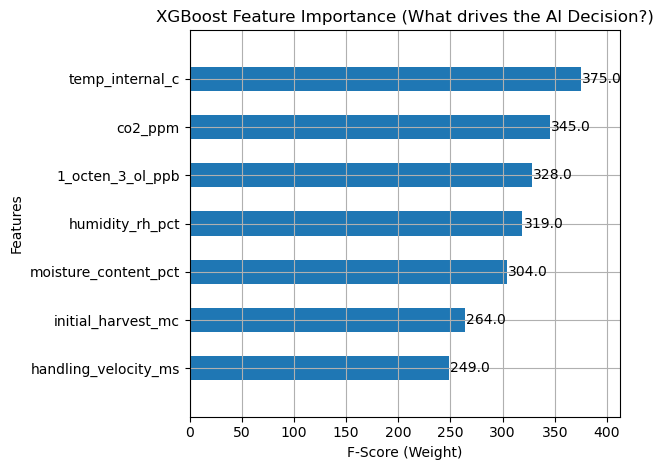

In [11]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

print("1. Loading Innovative Master Dataset...")
# Load the dataset you just created
df = pd.read_csv('innovative_master_data1.csv')

print("2. Preparing Data for XGBoost...")
# XGBoost needs categories to be numbers (0, 1, 2 instead of text)
le_policy = LabelEncoder()
df['policy_label'] = le_policy.fit_transform(df['recommended_policy'])

# --- FEATURE SELECTION ---
# We feed the AI the biological and mechanical features, but NOT the economic loss/cost columns 
# (The AI has to learn to predict the policy using only the sensor and metadata!)
features = [
    'temp_internal_c', 
    'humidity_rh_pct', 
    'co2_ppm', 
    'moisture_content_pct', 
    'handling_velocity_ms',   # Innovative: Mechanical Risk
    '1_octen_3_ol_ppb',       # Innovative: Specific Mold VOC
    'initial_harvest_mc'      # Innovative: Drying-Storage Nexus
]

X = df[features]
y = df['policy_label']

print("3. Splitting into Training (80%) and Testing (20%)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("4. Training the XGBoost Optimization Model...")
# Initialize the model (multi:softprob is for multi-class classification)
model = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=3, 
    eval_metric='mlogloss', 
    random_state=42,
    learning_rate=0.1,
    max_depth=5
)

# Train it!
model.fit(X_train, y_train)
print("Training Complete!\n")

print("-" * 40)
print("--- MODEL ACCURACY & EVALUATION ---")
print("-" * 40)
# Make predictions on the 20% test data the model has never seen
y_pred = model.predict(X_test)

# Print the final report mapping the numbers back to the text labels
print(classification_report(y_test, y_pred, target_names=le_policy.classes_))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# --- VISUALIZATION: FEATURE IMPORTANCE ---
print("Generating Feature Importance Graph (Close the graph window to finish script)...")
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=7, height=0.5)
plt.title('XGBoost Feature Importance (What drives the AI Decision?)')
plt.xlabel('F-Score (Weight)')
plt.ylabel('Features')
plt.tight_layout()
# Save the plot for your thesis!
plt.savefig('xgboost_feature_importance.png', dpi=300)
plt.show()

1. Loading the Innovative Dataset...
2. Scaling and Reshaping Data for LSTM...
3. Splitting into Training and Testing Sets...
4. Building the LSTM Neural Network...


C:\Users\Nandini\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5. Training the Model (This might take a few seconds)...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 11165.0127 - mae: 80.4511 - val_loss: 10603.5850 - val_mae: 78.8443
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11161.3486 - mae: 80.4426 - val_loss: 10599.8496 - val_mae: 78.8339
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11157.5234 - mae: 80.4337 - val_loss: 10596.1211 - val_mae: 78.8236
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11153.7393 - mae: 80.4253 - val_loss: 10592.3584 - val_mae: 78.8131
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11149.9111 - mae: 80.4165 - val_loss: 10588.6279 - val_mae: 78.8027
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11146.0713 - mae: 80.4075 - val_loss: 10584.9482 - val_mae: 78.7925
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11142.3096 - mae: 80.3995 - val_loss: 10581.1689 - val_mae: 78.7820
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11

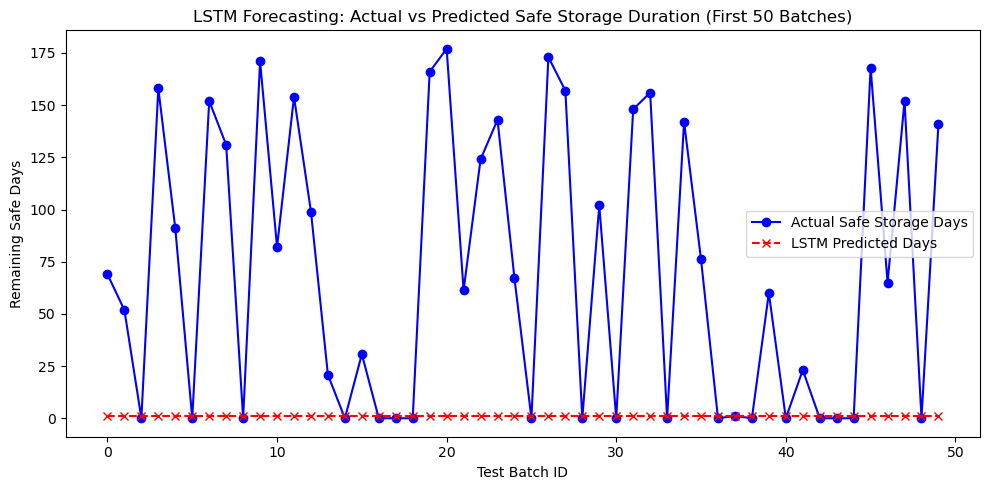

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, r2_score

print("1. Loading the Innovative Dataset...")
df = pd.read_csv('innovative_master_data1.csv')

# --- FEATURE SELECTION ---
# We feed the LSTM the environmental and chemical markers
features = [
    'temp_internal_c', 
    'humidity_rh_pct', 
    'co2_ppm', 
    'moisture_content_pct',
    '1_octen_3_ol_ppb',       # The Mold Alarm
    'handling_velocity_ms',   # Mechanical Vulnerability
    'storage_days'            # How long it's already been in the silo
]

X = df[features].values
y = df['ssd_remaining_days'].values # TARGET: How many safe days are left?

print("2. Scaling and Reshaping Data for LSTM...")
# Neural networks need data scaled between 0 and 1
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

# LSTM requires a 3D input shape: [samples, time steps, features]
# We will treat each row as a single time-step snapshot for this batch
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

print("3. Splitting into Training and Testing Sets...")
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y, test_size=0.2, random_state=42)

print("4. Building the LSTM Neural Network...")
model = Sequential()
# Layer 1: The LSTM "Memory" Layer
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dropout(0.2)) # Prevents overfitting

# Layer 2: A Dense "Reasoning" Layer
model.add(Dense(32, activation='relu'))

# Layer 3: The Output Layer (Predicting a single number: remaining days)
model.add(Dense(1, activation='linear'))

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("5. Training the Model (This might take a few seconds)...")
# Train the model for 50 cycles (epochs)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("\n6. Evaluating the LSTM Predictions...")
y_pred = model.predict(X_test)

# Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} Days")
print(f"R-Squared (Accuracy Score): {r2*100:.2f}%")

print("\n7. Generating Prediction Accuracy Graph...")
# --- VISUALIZATION: Actual vs Predicted ---
plt.figure(figsize=(10, 5))
plt.plot(y_test[:50], label='Actual Safe Storage Days', marker='o', color='blue')
plt.plot(y_pred[:50], label='LSTM Predicted Days', marker='x', color='red', linestyle='dashed')
plt.title('LSTM Forecasting: Actual vs Predicted Safe Storage Duration (First 50 Batches)')
plt.xlabel('Test Batch ID')
plt.ylabel('Remaining Safe Days')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_ssd_predictions.png', dpi=300)
plt.show()